# Assignment 2: Training models via iterative approach

This notebook fits the provided `A2.csv` data to the nonlinear model

$$
\hat{y} = c_0 + c_1 e^{c_2 x}
$$

The parameters are learned with batch gradient descent. The notebook follows the five assignment tasks, checks the analytic gradient numerically, and visualizes both optimization and the fitted curve.

## Analysis map

1. Load and validate the 100 observations from `data/A2.csv`.
2. Plot the observed relationship between `x` and `y`.
3. Define the loss function, derive the gradients, and verify them with finite differences.
4. Apply the update rules with batch gradient descent.
5. Show loss over iterations, fitted values, residuals, and final coefficients.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


class DualFormatTable:
    """Render tables as HTML in notebooks and LaTeX in PDF exports."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def _repr_html_(self) -> str:
        return self.frame.to_html(index=False)

    def _repr_latex_(self) -> str:
        return self.frame.to_latex(index=False, escape=True)


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.constrained_layout.use": True,
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
DATA_PATH = Path("data/A2.csv")

## Data source and validation

`x` is the predictor and `y` is the response. The CSV is the single source of truth; all later calculations use the validated arrays created below.

In [2]:
raw = pd.read_csv(DATA_PATH)

assert raw.shape == (100, 2), raw.shape
assert list(raw.columns) == ["X", "Y"]
assert all(pd.api.types.is_numeric_dtype(raw[column]) for column in raw.columns)

data = raw.rename(columns={"X": "x", "Y": "y"}).copy()
x = data["x"].to_numpy(dtype=float)
y = data["y"].to_numpy(dtype=float)

assert x.ndim == y.ndim == 1
assert x.shape == y.shape == (100,)
assert np.isfinite(x).all() and np.isfinite(y).all()
assert x.min() >= 0 and x.max() <= 5
assert y.min() > 0
assert np.ptp(x) > 0 and np.ptp(y) > 0

print(f"Loaded {len(data)} observations from {DATA_PATH}.")
print(f"x range: [{x.min():.4f}, {x.max():.4f}]")
print(f"y range: [{y.min():.4f}, {y.max():.4f}]")
display(DualFormatTable(data.head(10).round(6)))
display(data.describe().T[["count", "mean", "std", "min", "max"]].round(6))

Loaded 100 observations from data/A2.csv.
x range: [0.0108, 4.9783]
y range: [0.9493, 1.9707]


x,y
4.072280,0.981321
1.724332,1.124653
1.901981,1.042435
4.914068,0.949332
1.165868,1.186925
1.792998,1.084234
2.152753,1.071854
3.229062,1.016997
3.185309,1.015326
4.520140,0.957779


,count,mean,std,min,max
x,100.000000,2.730601,1.445092,0.010773,4.978255
y,100.000000,1.119514,0.228856,0.949332,1.970695


## Data overview

The scatter plot shows the shape that the model must capture: `y` decreases quickly for small `x` and then approaches a nearly constant level.

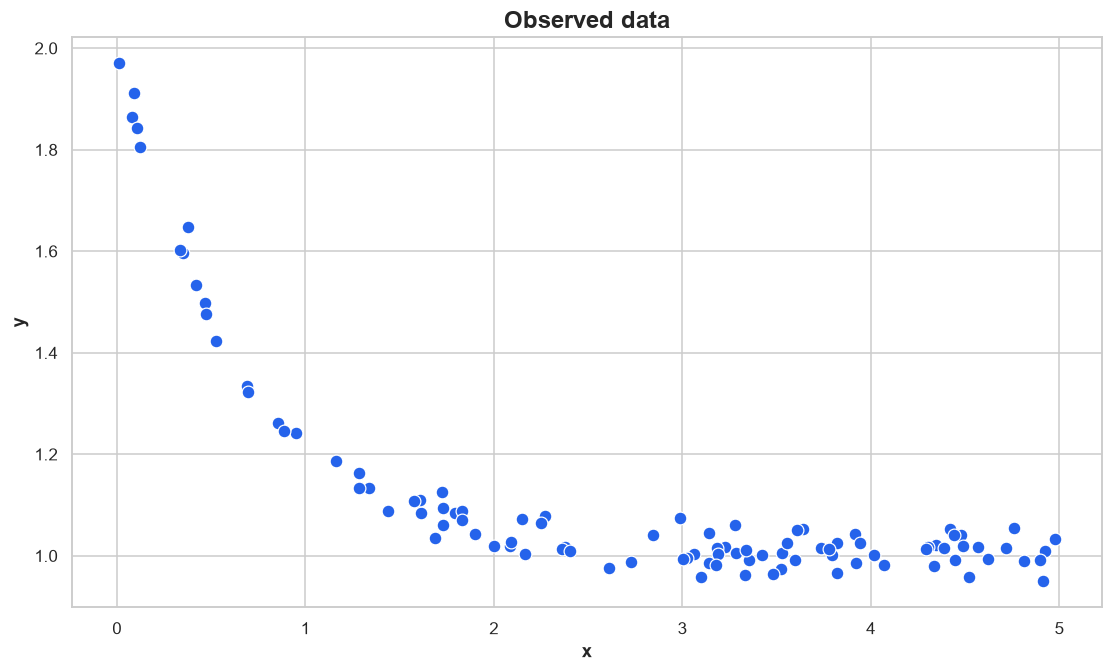

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=x,
    y=y,
    s=70,
    color="#2563eb",
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
ax.set_title("Observed data", fontsize=16)
ax.set_xlabel("x")
ax.set_ylabel("y")
display(fig)
plt.close(fig)

## 1. Error/loss function

For observation `i`, define the residual as `r_i = y_hat_i - y_i`. I use half mean squared error so the factor of 2 cancels from every gradient:

$$
L(c_0,c_1,c_2) = \frac{1}{2n} \sum_{i=1}^{n} r_i^2, \qquad r_i = c_0 + c_1 e^{c_2 x_i} - y_i.
$$

The loss is measured in squared `y` units. Lower values indicate that the fitted curve is closer to the observed data.

## 2. Gradients of the coefficients

Using the chain rule:

$$
\frac{\partial L}{\partial c_0} = \frac{1}{n} \sum_{i=1}^{n} r_i,
$$

$$
\frac{\partial L}{\partial c_1} = \frac{1}{n} \sum_{i=1}^{n} r_i e^{c_2 x_i},
$$

$$
\frac{\partial L}{\partial c_2} = \frac{1}{n} \sum_{i=1}^{n} r_i c_1 x_i e^{c_2 x_i}.
$$

In [4]:
def predict(x_values: np.ndarray, coefficients: np.ndarray) -> np.ndarray:
    """Evaluate c0 + c1 * exp(c2 * x)."""

    x_array = np.asarray(x_values, dtype=float)
    coefficient_array = np.asarray(coefficients, dtype=float)
    if coefficient_array.shape != (3,):
        raise ValueError("coefficients must contain c0, c1, and c2")
    c0, c1, c2 = coefficient_array
    return c0 + c1 * np.exp(c2 * x_array)


def loss(coefficients: np.ndarray, x_values: np.ndarray, y_values: np.ndarray) -> float:
    """Return half mean squared error for the exponential model."""

    residual = predict(x_values, coefficients) - np.asarray(y_values, dtype=float)
    return float(0.5 * np.mean(residual**2))


def gradient(
    coefficients: np.ndarray, x_values: np.ndarray, y_values: np.ndarray
) -> np.ndarray:
    """Return the analytic gradient [dL/dc0, dL/dc1, dL/dc2]."""

    coefficient_array = np.asarray(coefficients, dtype=float)
    x_array = np.asarray(x_values, dtype=float)
    y_array = np.asarray(y_values, dtype=float)
    c0, c1, c2 = coefficient_array
    exponential_term = np.exp(c2 * x_array)
    residual = c0 + c1 * exponential_term - y_array
    return np.array(
        [
            np.mean(residual),
            np.mean(residual * exponential_term),
            np.mean(residual * c1 * x_array * exponential_term),
        ],
        dtype=float,
    )


initial_coefficients = np.array([1.0, 1.0, -1.0])
analytic_gradient = gradient(initial_coefficients, x, y)
epsilon = 1e-6
finite_difference_gradient = np.empty(3)
for index in range(3):
    delta = np.zeros(3)
    delta[index] = epsilon
    finite_difference_gradient[index] = (
        loss(initial_coefficients + delta, x, y)
        - loss(initial_coefficients - delta, x, y)
    ) / (2 * epsilon)

gradient_check = pd.DataFrame(
    {
        "analytic": analytic_gradient,
        "finite_difference": finite_difference_gradient,
        "absolute_error": np.abs(analytic_gradient - finite_difference_gradient),
    },
    index=["c0", "c1", "c2"],
).reset_index(names="coefficient")
display(DualFormatTable(gradient_check.round(10)))
assert np.allclose(analytic_gradient, finite_difference_gradient, rtol=1e-5, atol=1e-8)
print("Analytic gradient agrees with the finite-difference check.")

coefficient,analytic,finite_difference,absolute_error
c0,0.054132,0.054132,0.000000
c1,0.015868,0.015868,0.000000
c2,0.014259,0.014259,0.000000


Analytic gradient agrees with the finite-difference check.


## 3. Update rules

With learning rate `eta` and iteration index `t`, update all coefficients simultaneously:

$$
c_j^{(t+1)} = c_j^{(t)} - \eta \frac{\partial L}{\partial c_j}, \qquad j \in \{0,1,2\}.
$$

The implementation below stores the full coefficient and loss history so the optimization path can be inspected visually.

## 4. Implement gradient descent

The function below applies the batch update to all 100 observations at each iteration. It records every coefficient vector and loss value, and raises an error if a non-finite value appears.

In [5]:
def gradient_descent(
    x_values: np.ndarray,
    y_values: np.ndarray,
    initial: np.ndarray,
    learning_rate: float,
    n_iterations: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Run batch gradient descent and return coefficient and loss histories."""

    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive")
    if n_iterations < 1:
        raise ValueError("n_iterations must be positive")

    coefficients = np.asarray(initial, dtype=float).copy()
    if coefficients.shape != (3,):
        raise ValueError("initial must contain c0, c1, and c2")

    coefficient_history = np.empty((n_iterations + 1, 3), dtype=float)
    loss_history = np.empty(n_iterations + 1, dtype=float)
    coefficient_history[0] = coefficients
    loss_history[0] = loss(coefficients, x_values, y_values)

    for iteration in range(n_iterations):
        coefficients -= learning_rate * gradient(coefficients, x_values, y_values)
        if not np.isfinite(coefficients).all():
            raise FloatingPointError(
                "gradient descent produced non-finite coefficients"
            )
        coefficient_history[iteration + 1] = coefficients
        loss_history[iteration + 1] = loss(coefficients, x_values, y_values)

    assert np.isfinite(loss_history).all()
    return coefficient_history, loss_history

In [6]:
learning_rate = 0.2
n_iterations = 20_000
coefficient_history, loss_history = gradient_descent(
    x, y, initial_coefficients, learning_rate, n_iterations
)

final_coefficients = coefficient_history[-1]
final_loss = loss_history[-1]
final_gradient = gradient(final_coefficients, x, y)
checkpoint_iterations = np.array([0, 1, 10, 100, 1_000, 10_000, n_iterations])
checkpoint_table = pd.DataFrame(
    coefficient_history[checkpoint_iterations],
    columns=["c0", "c1", "c2"],
)
checkpoint_table.insert(0, "iteration", checkpoint_iterations)
checkpoint_table["loss"] = loss_history[checkpoint_iterations]

display(DualFormatTable(checkpoint_table.round(8)))
print(f"learning rate = {learning_rate}")
print(f"initial loss = {loss_history[0]:.10f}")
print(f"final loss = {final_loss:.10f}")
print(f"final gradient norm = {np.linalg.norm(final_gradient):.10e}")
print("final coefficients:")
for name, value in zip(["c0", "c1", "c2"], final_coefficients):
    print(f"  {name} = {value:.10f}")

assert loss_history[-1] < loss_history[0]
assert np.all(np.diff(loss_history) <= 1e-12)
assert final_coefficients[2] < 0
assert np.allclose(final_coefficients, [1.00335, 0.99927, -1.52987], atol=5e-4)
assert final_loss < 0.00038

iteration,c0,c1,c2,loss
0,1.000000,1.000000,-1.000000,0.003006
1,0.989174,0.996826,-1.002852,0.002400
10,0.955533,0.980928,-1.017062,0.001354
100,0.968855,0.933183,-1.082692,0.000946
1000,0.994293,0.964467,-1.356822,0.000447
10000,1.003347,0.999251,-1.529766,0.000378
20000,1.003353,0.999271,-1.529875,0.000378


learning rate = 0.2
initial loss = 0.0030059489
final loss = 0.0003777068
final gradient norm = 1.4616895069e-10
final coefficients:
  c0 = 1.0033525768
  c1 = 0.9992714858
  c2 = -1.5298751857


## 5. Loss over iterations

The left panel uses a logarithmic vertical axis so the early and late improvements are both visible. The right panel shows how each coefficient moves from its initial value toward the fitted solution.

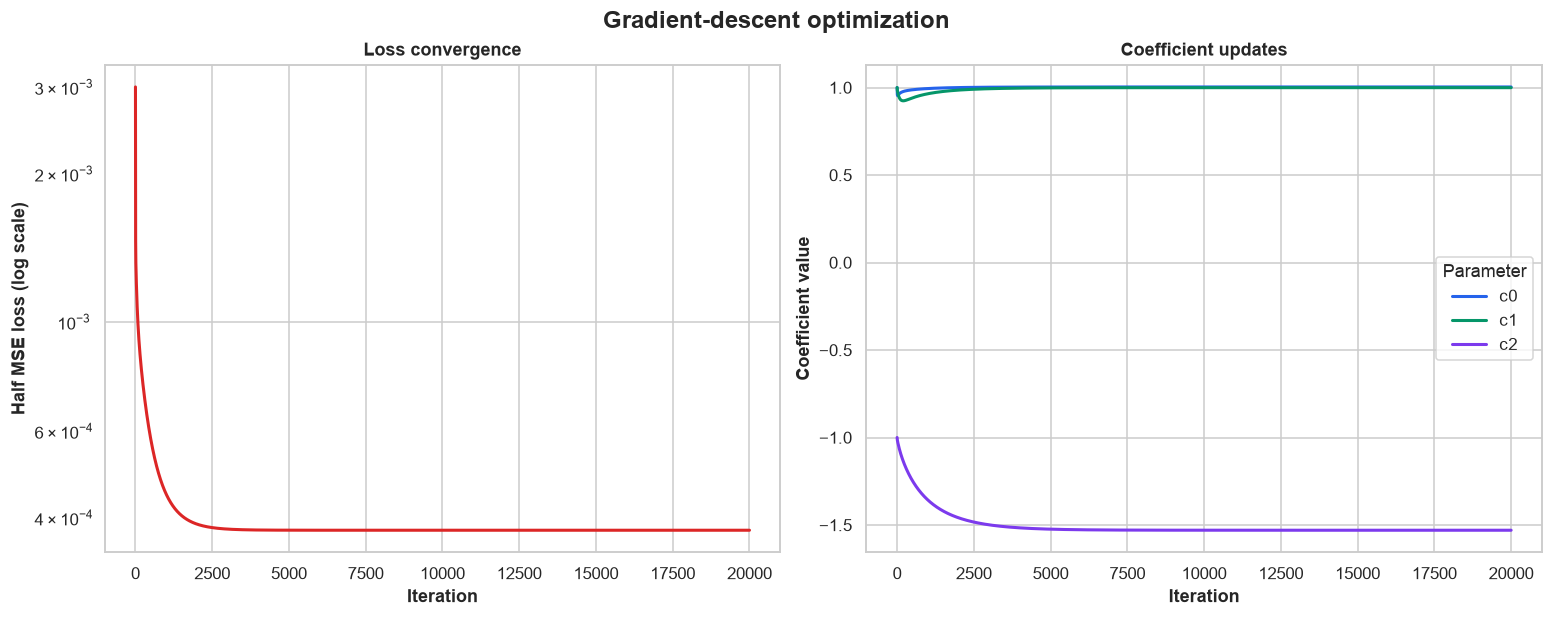

In [7]:
iterations = np.arange(n_iterations + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(iterations, loss_history, color="#dc2626", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("Loss convergence")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Half MSE loss (log scale)")

for index, name, color in zip(
    range(3), ["c0", "c1", "c2"], ["#2563eb", "#059669", "#7c3aed"]
):
    axes[1].plot(
        iterations, coefficient_history[:, index], label=name, color=color, linewidth=2
    )
axes[1].set_title("Coefficient updates")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Coefficient value")
axes[1].legend(title="Parameter")
fig.suptitle("Gradient-descent optimization", fontsize=16, fontweight="bold")
display(fig)
plt.close(fig)

## Fitted model

The fitted curve is evaluated on a dense grid across the observed `x` range. Restricting the plot to that range keeps the visual comparison interpolative rather than implying unsupported behavior outside the data.

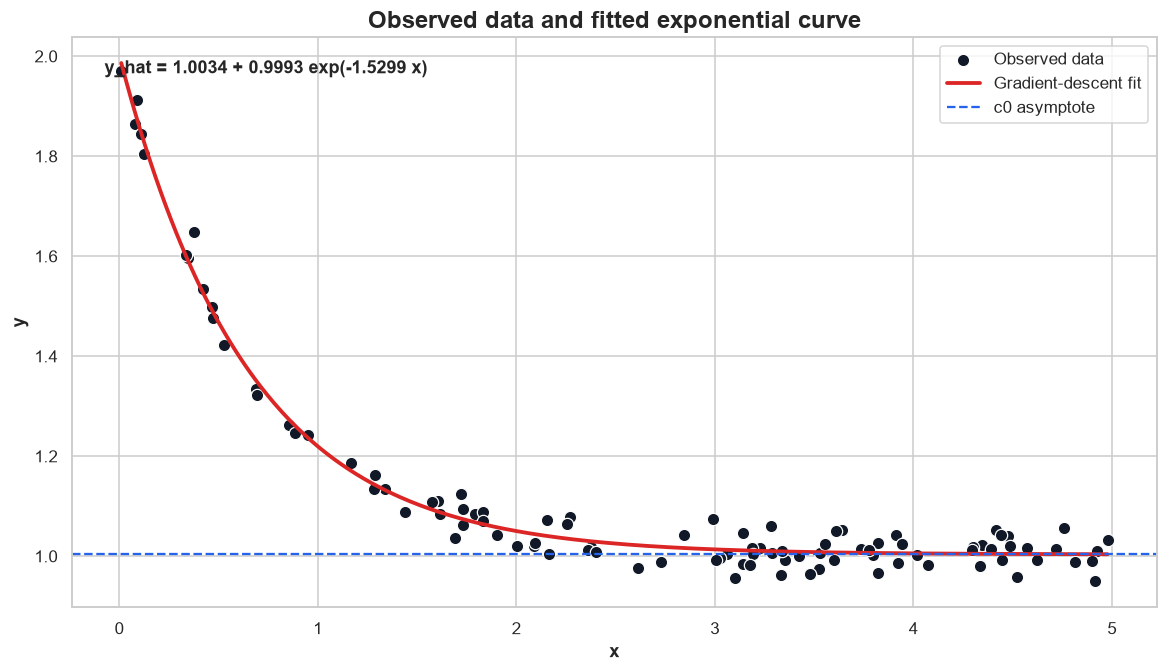

In [8]:
x_grid = np.linspace(x.min(), x.max(), 400)
y_grid = predict(x_grid, final_coefficients)
equation_text = (
    f"y_hat = {final_coefficients[0]:.4f} + "
    f"{final_coefficients[1]:.4f} exp({final_coefficients[2]:.4f} x)"
)

fig, ax = plt.subplots(figsize=(10.5, 6))
sns.scatterplot(
    x=x,
    y=y,
    s=65,
    color="#111827",
    edgecolor="white",
    linewidth=0.8,
    label="Observed data",
    ax=ax,
)
ax.plot(x_grid, y_grid, color="#dc2626", linewidth=2.5, label="Gradient-descent fit")
ax.axhline(
    final_coefficients[0],
    color="#2563eb",
    linestyle="--",
    linewidth=1.5,
    label="c0 asymptote",
)
ax.text(0.03, 0.96, equation_text, transform=ax.transAxes, va="top", fontweight="bold")
ax.set_title("Observed data and fitted exponential curve", fontsize=16)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
display(fig)
plt.close(fig)

## Evaluation

The residuals are `y_hat - y`. I report SSE, MSE, RMSE, and R-squared as descriptive measures of fit. These summarize this sample and do not establish that changing `x` causes a change in `y`.

In [9]:
fitted_values = predict(x, final_coefficients)
residuals = fitted_values - y
sse = float(np.sum(residuals**2))
mse = float(np.mean(residuals**2))
rmse = float(np.sqrt(mse))
sst = float(np.sum((y - y.mean()) ** 2))
r_squared = float(1 - sse / sst)

metrics = pd.DataFrame(
    {
        "metric": ["SSE", "MSE", "RMSE", "R-squared"],
        "value": [sse, mse, rmse, r_squared],
        "interpretation": [
            "sum of squared residuals",
            "mean squared residual",
            "typical residual size in y units",
            "fraction of sample variation explained",
        ],
    }
)
display(DualFormatTable(metrics.round(8)))
print(f"R-squared = {r_squared:.6f}")
print(f"RMSE = {rmse:.6f} y units")

assert np.isclose(mse, 2 * final_loss)
assert sse >= 0 and mse >= 0 and rmse >= 0
assert 0 < r_squared < 1

metric,value,interpretation
SSE,0.075541,sum of squared residuals
MSE,0.000755,mean squared residual
RMSE,0.027485,typical residual size in y units
R-squared,0.985431,fraction of sample variation explained


R-squared = 0.985431
RMSE = 0.027485 y units


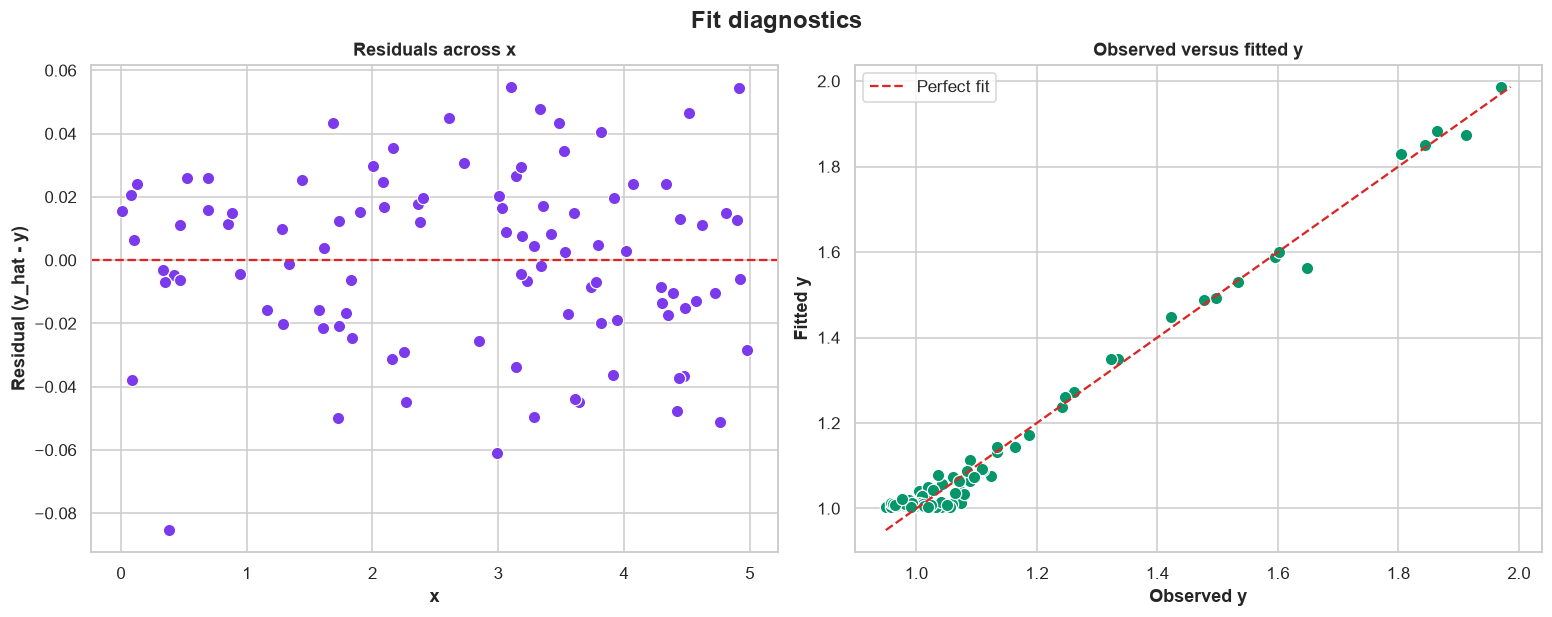

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(x, residuals, color="#7c3aed", s=65, edgecolor="white", linewidth=0.8)
axes[0].axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals across x")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Residual (y_hat - y)")

limits = [min(y.min(), fitted_values.min()), max(y.max(), fitted_values.max())]
padding = 0.05 * (limits[1] - limits[0])
axes[1].scatter(
    y, fitted_values, color="#059669", s=65, edgecolor="white", linewidth=0.8
)
axes[1].plot(
    limits, limits, color="#dc2626", linestyle="--", linewidth=1.5, label="Perfect fit"
)
axes[1].set_xlim(limits[0] - padding, limits[1] + padding)
axes[1].set_ylim(limits[0] - padding, limits[1] + padding)
axes[1].set_title("Observed versus fitted y")
axes[1].set_xlabel("Observed y")
axes[1].set_ylabel("Fitted y")
axes[1].legend()
fig.suptitle("Fit diagnostics", fontsize=16, fontweight="bold")
display(fig)
plt.close(fig)

## Interpretation

- `c0` is the limiting `y` level as `x` becomes large because the fitted `c2` is negative.
- `c1` controls the exponential contribution. At `x = 0`, the model value is `c0 + c1`.
- `c2` is the decay rate per unit of `x`; its negative sign means the exponential contribution decreases as `x` increases.
- The fitted curve is an interpolation across the observed `x` range. The fit alone is not evidence of causation, and extrapolation outside the observed range may be unreliable.

In [11]:
print("Final assignment results")
print(f"Loss function: half MSE = (1 / (2n)) * sum(residual^2)")
print("Gradient: analytic gradient checked against finite differences")
print("Update: coefficient = coefficient - learning_rate * gradient")
print(f"Iterations: {n_iterations:,}")
print(f"Final loss: {final_loss:.10f}")
for name, value in zip(["c0", "c1", "c2"], final_coefficients):
    print(f"{name} = {value:.10f}")
print(f"SSE = {sse:.10f}")
print(f"R-squared = {r_squared:.6f}")

Final assignment results
Loss function: half MSE = (1 / (2n)) * sum(residual^2)
Gradient: analytic gradient checked against finite differences
Update: coefficient = coefficient - learning_rate * gradient
Iterations: 20,000
Final loss: 0.0003777068
c0 = 1.0033525768
c1 = 0.9992714858
c2 = -1.5298751857
SSE = 0.0755413539
R-squared = 0.985431


## Final answers

1. **Error/loss:** use half mean squared error, `L = (1 / (2n)) * sum((y_hat_i - y_i)^2)`.
2. **Gradients:** the notebook derives and implements `dL/dc0`, `dL/dc1`, and `dL/dc2`; the finite-difference table confirms the implementation.
3. **Update rules:** each coefficient is updated with `c_j_new = c_j - eta * dL/dc_j`.
4. **Implementation:** batch gradient descent reads `data/A2.csv`, validates the inputs, and runs with learning rate `0.2` for `20,000` iterations.
5. **Loss and coefficients:** the checkpoint table and convergence plot show the loss decreasing. The final-results output reports the resulting loss and coefficients, approximately `c0 = 1.0034`, `c1 = 0.9993`, and `c2 = -1.5299`.